In [ ]:
# ============================================================
# Semantic vs Brain Similarity Analysis (Weighted RSA version)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from scipy import stats

# --- Prepare output folders ---
os.makedirs("results", exist_ok=True)
os.makedirs("figures", exist_ok=True)

# --- Load label data ---
labels = np.load("../data/kay_labels.npy", allow_pickle=True)
if labels.shape[0] == 4:
    labels = labels.T
labels = labels.astype(str)
label_data = labels[:, :4]

# --- Compute weighted label similarity matrix ---
n_images = label_data.shape[0]
weights = [4, 3, 2, 1]
label_similarity = np.zeros((n_images, n_images))

for i in range(n_images):
    for j in range(n_images):
        score = sum(weights[k] for k in range(4) if label_data[i, k] == label_data[j, k])
        label_similarity[i, j] = score

# --- Load fMRI data ---
data = np.load("../data/kay_images.npz")
responses = data["responses"]
roi = data["roi"]
roi_names = data["roi_names"]

# --- Run RSA across ROIs ---
results = {}
iu = np.triu_indices(n_images, k=1)
flat_label_sim = label_similarity[iu]

for roi_idx, roi_name in enumerate(roi_names):
    if roi.ndim == 1:
        voxel_mask = (roi == roi_idx)
    else:
        voxel_mask = (roi[0] == roi_idx)

    if voxel_mask.sum() == 0:
        print(f"Skipping {roi_name} (no voxels)")
        continue

    # Z-score responses per voxel
    responses_roi = responses[:, voxel_mask]
    responses_roi = (responses_roi - responses_roi.mean(axis=0)) / (responses_roi.std(axis=0) + 1e-8)

    brain_corr = np.corrcoef(responses_roi)
    flat_brain_corr = brain_corr[iu]

    # Spearman correlation
    rho, p_value = stats.spearmanr(flat_label_sim, flat_brain_corr)
    results[roi_name] = {'Spearman_rho': rho, 'p_value': p_value}

    # Regression line
    m, b = np.polyfit(flat_label_sim, flat_brain_corr, 1)
    x_line = np.array([flat_label_sim.min(), flat_label_sim.max()])
    y_line = m * x_line + b

    # Mean per bin
    unique_bins = np.unique(flat_label_sim)
    means = []
    counts = []
    for bn in unique_bins:
        mask = flat_label_sim == bn
        means.append(flat_brain_corr[mask].mean())
        counts.append(mask.sum())

    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.scatter(flat_label_sim, flat_brain_corr, alpha=0.1,
                color='steelblue', edgecolors='none', s=5)
    ax1.plot(x_line, y_line, color='red', linewidth=2,
             label=f'slope={m:.4f}')
    ax1.set_xlabel("Semantic Similarity (Weighted)")
    ax1.set_ylabel("Brain Similarity (Pearson)")
    ax1.set_title(f"{roi_name} — Scatter")
    ax1.legend()
    ax1.grid(True, linestyle=':')

    ax2.bar(unique_bins, means, color='steelblue', alpha=0.7, width=0.6)
    ax2.axhline(0, color='black', linewidth=0.5)
    ax2.set_xlabel("Semantic Similarity (Weighted)")
    ax2.set_ylabel("Mean Brain Similarity")
    ax2.set_title(f"{roi_name} — Mean per Bin")
    ax2.grid(True, linestyle=':')

    plt.suptitle(f"{roi_name} — Spearman rho={rho:.4f}", fontsize=12)
    plt.tight_layout()
    plt.savefig(f"figures/{roi_name}_scatter.png", dpi=300)
    plt.close()

    print(f"{roi_name}: rho = {rho:.4f}, p = {p_value:.6f}")

# --- Save all results ---
df = pd.DataFrame.from_dict(results, orient='index').reset_index()
df.columns = ['ROI', 'Spearman_rho', 'p_value']
df.to_csv("results/rsa_weighted.csv", index=False)

print("\n✅ RSA analysis completed.")
print(df)
print("\nFigures saved in /figures and results in /results ✅")

Skipping Other (no voxels)
V1: rho = 0.0019, p = 0.018725
V2: rho = 0.0042, p = 0.000000
V3: rho = 0.0066, p = 0.000000


C:\Users\NilGooN\AppData\Local\Temp\ipykernel_10776\3121283518.py:98: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\NilGooN\AppData\Local\Temp\ipykernel_10776\3121283518.py:99: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(f"figures/{roi_name}_scatter.png", dpi=300)


V3A: rho = 0.0122, p = 0.000000
V3B: rho = 0.0227, p = 0.000000
V4: rho = 0.0177, p = 0.000000
LatOcc: rho = 0.0381, p = 0.000000

✅ RSA analysis completed.
      ROI  Spearman_rho        p_value
0      V1      0.001900   1.872482e-02
1      V2      0.004184   2.261284e-07
2      V3      0.006602   3.145956e-16
3     V3A      0.012179   2.665410e-51
4     V3B      0.022720  7.329380e-174
5      V4      0.017652  9.834448e-106
6  LatOcc      0.038064   0.000000e+00

Figures saved in /figures and results in /results ✅


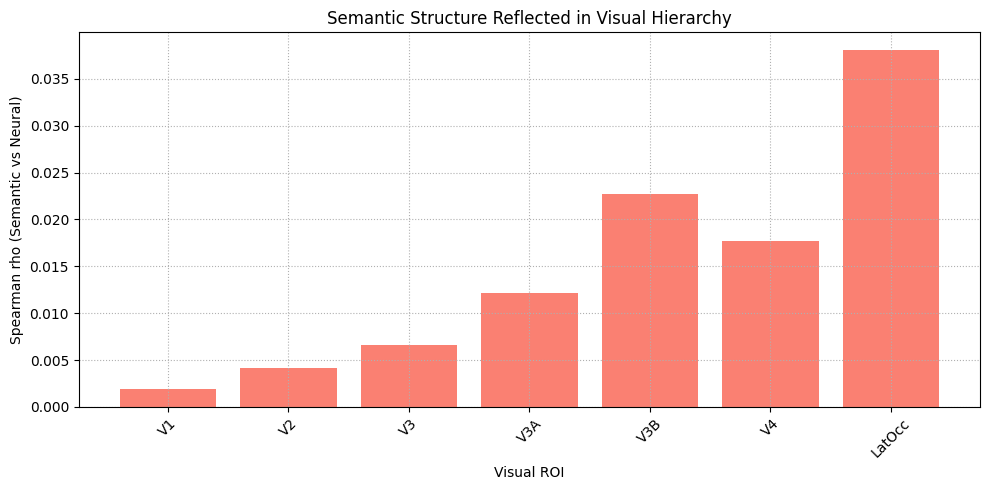

✅ saved


In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("results/rsa_weighted.csv")

plt.figure(figsize=(10, 5))
plt.bar(df['ROI'], df['Spearman_rho'], color='salmon')
plt.xlabel("Visual ROI")
plt.ylabel("Spearman rho (Semantic vs Neural)")
plt.title("Semantic Structure Reflected in Visual Hierarchy")
plt.xticks(rotation=45)
plt.grid(True, linestyle=':')
plt.tight_layout()
plt.savefig("figures/rsa_summary_bar.png", dpi=300)
plt.show()
print("✅ saved")